In [4]:
import numpy as np
import pandas as pd
import xgboost as xg
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [5]:
!pip install opendatasets
import opendatasets as od
od.download('https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset')

Skipping, found downloaded files in "./forest-cover-type-dataset" (use force=True to force download)


In [6]:
df = pd.read_csv('/content/forest-cover-type-dataset/covtype.csv')
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [7]:
df['Cover_Type'].unique()

array([5, 2, 1, 7, 3, 6, 4])

In [8]:
print(df.columns.tolist())

['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Cover_Type']


In [9]:
print(df.isnull())

        Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0           False   False  False                             False   
1           False   False  False                             False   
2           False   False  False                             False   
3           False   False  False                             False   
4           False   False  False                             False   
...           ...     ...    ...                               ...   
581007      False   False  False                             False   
581008      False   False  False                             False   
581009      False   False  False                             False   
581010      False   False  False                             False   
581011      False   False  False                             False   

        Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                                False                            False   
1        

In [10]:
print(df.isnull().values.any())

False


In [11]:
# Separate features and target
X = df.drop("Cover_Type", axis=1)   # X = all columns except Cover_Type
Y = df["Cover_Type"]                # Y = only Cover_Type column

# Optional: check shapes
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (581012, 54)
Y shape: (581012,)


In [12]:
# 🔧 FIX: Convert classes from 1–7 to 0–6
Y = Y - 1

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [14]:
XG = xg.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

In [15]:
XG.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [20:29:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
Y_pred = XG.predict(X_test)

In [17]:
print('Accuarcy Score: ', accuracy_score(Y_test, Y_pred))

Accuarcy Score:  0.8711823274786366


In [18]:
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     42557
           1       0.87      0.90      0.88     56500
           2       0.90      0.91      0.91      7121
           3       0.91      0.86      0.89       526
           4       0.89      0.59      0.71      1995
           5       0.85      0.82      0.83      3489
           6       0.94      0.92      0.93      4015

    accuracy                           0.87    116203
   macro avg       0.89      0.83      0.86    116203
weighted avg       0.87      0.87      0.87    116203



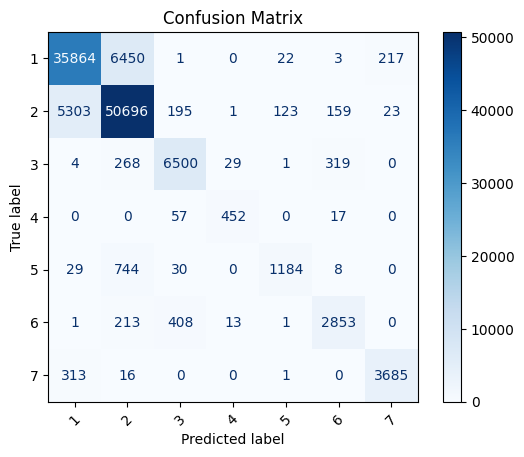

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# Create a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5, 6, 7])  # original labels (1–7)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

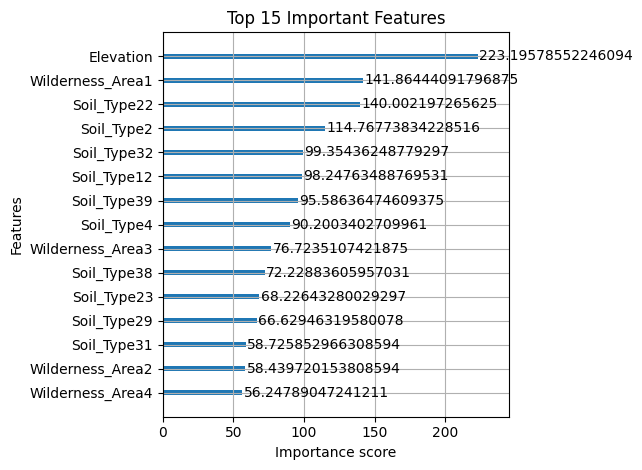

In [20]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Correct way to plot feature importance
xgb.plot_importance(XG, max_num_features=15, importance_type='gain')
plt.title("Top 15 Important Features")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [22]:
# Split features and target
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
dt = DecisionTreeClassifier(random_state=42)

In [25]:
# Train the model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [26]:
# Predict on test set
y_pred = dt.predict(X_test)

In [27]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Decision Tree accuracy: {accuracy:.4f}')

Decision Tree accuracy: 0.9390
